# Professors Code: sampleScript

This is the IP address: 193.136.173.58
This is the DNS name: 20.172.136.193.in-addr.arpa.
This is the resolved DNS with the 20.172.136.193.in-addr.arpa. and with 'PTR: dns.ua.pt.
Number of UDP flows for each source IP: src_ip
192.168.101.100     372
192.168.101.101    1100
192.168.101.102      83
192.168.101.103     674
192.168.101.104     251
                   ... 
192.168.101.95      271
192.168.101.96      285
192.168.101.97      548
192.168.101.98      355
192.168.101.99      477
Name: up_bytes, Length: 196, dtype: int64
Number of UDP flows to port 443, for each source IP: src_ip
192.168.101.100     9
192.168.101.101    23
192.168.101.102     2
192.168.101.103     9
192.168.101.104     3
                   ..
192.168.101.95      6
192.168.101.96      8
192.168.101.97     17
192.168.101.98     12
192.168.101.99     18
Name: up_bytes, Length: 195, dtype: int64
Average number of downloaded bytes, per flow, for each source IP: src_ip
192.168.101.100    91931.978359
192.168.101.101    

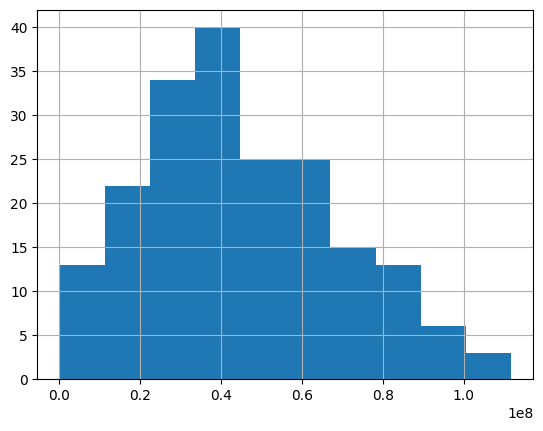

AttributeError: module 'dns.reversename' has no attribute 'ReverseName'

In [46]:
import pandas as pd
import numpy as np
import ipaddress
import dns.resolver
import dns.reversename
import pygeoip
import matplotlib.pyplot as plt 

datafile='./../dataset1/data1.parquet'

# IP geolocalization
gi = pygeoip.GeoIP('./../GeoIP_DBs/GeoIP.dat')
# Get AS number
gi2 = pygeoip.GeoIP('./../GeoIP_DBs/GeoIPASNum.dat')


# DNS resolution
addr = dns.resolver.resolve("www.ua.pt", 'A')
print("This is the IP address: " + addr[0].to_text())

# Reverse DNS resolution    
name = dns.reversename.from_address("193.136.172.20")
print("This is the DNS name: " + str(name))
addr = dns.resolver.resolve(name, 'PTR')
print("This is the resolved DNS with the " + str(name) + " and with 'PTR: " + addr[0].to_text())
# for a in addr:
#     print("This is the IP address: " + a.to_text())

### Read parquet data files
data = pd.read_parquet(datafile)

# Just the UDP flows
udpF = data.loc[data['proto']=='udp']

#Number of UDP flows for each source IP
nudpF=data.loc[data['proto']=='udp'].groupby(['src_ip'])['up_bytes'].count()
print("Number of UDP flows for each source IP: " + str(nudpF))

#Number of UDP flows to port 443, for each source IP
nudpF443=data.loc[(data['proto']=='udp')&(data['port']==443)].groupby(['src_ip'])['up_bytes'].count()
print("Number of UDP flows to port 443, for each source IP: " + str(nudpF443))

# Average number of downloaded bytes, per flow, for each source IP
avgUp=data.groupby(['src_ip'])['down_bytes'].mean()
print("Average number of downloaded bytes, per flow, for each source IP: " + str(avgUp))

# Total uploaded bytes to destination port 443, for each source IP, ordered from larger amount to lowest amount
upS=data.loc[((data['port']==443))].groupby(['src_ip'])['up_bytes'].sum().sort_values(ascending=False)

# Histogram of the total uploaded bytes to destination port 443, by source IP
upS =data.loc[((data['port']==443))].groupby(['src_ip'])['up_bytes'].sum().hist()
plt.show()

# Is destination IPv4 a public address?
NET = ipaddress.IPv4Network('192.168.100.0/24')
bpublic = data.apply(lambda x: ipaddress.IPv4Address(x['dst_ip']) not in NET, axis=1)
bdf = pd.DataFrame(bpublic).rename(columns={0:'bpublic'})

# Geolocalization of public destination adddress
# cc = data[bpublic]['dst_ip'].apply(lambda y:gi.country_code_by_addr(y)).to_frame(name='cc')

# Organization of public destination adddress
# org = data[bpublic]['dst_ip'].apply(lambda y:gi2.org_by_addr(y)).to_frame(name='org')

# DNS resolution of public destination adddress if dns not resolved return NaN
# def resolve_ptr(ip):
#     try:
#         reverse_name = dns.reversename.from_address(ip)
#         ptr_result = dns.resolver.resolve(str(reverse_name), 'PTR')
#         return str(ptr_result[0])
#     except dns.exception.DNSException:
#         return pd.NA

# ptr = data[bpublic]['dst_ip'].apply(resolve_ptr).to_frame(name='ptr')
# ptr = data[bpublic]['dst_ip'].apply(lambda y: pd.NA if dns.reversename.from_address(y) else dns.resolver.resolve(str(dns.reversename.from_address(y)), 'PTR')[0]).to_frame(name='ptr')
ptr = data[bpublic]['dst_ip'].apply(lambda y: pd.NA if dns.resolver.resolve(str(dns.reversename.from_address(y)), 'PTR') is None else str(dns.resolver.resolve(str(dns.reversename.from_address(y)), 'PTR')[0])).to_frame(name='ptr')
print(ptr)

## Concating useful information to the dataset

In [43]:
# concat data with bpublic, cc and org on the collum
data = pd.concat([data, cc, bdf, org, ptr], axis=1)

print(data)

        timestamp           src_ip           dst_ip proto  port  up_bytes  \
index                                                                       
348325    1286969   192.168.101.56  192.168.101.228   udp    53       248   
348326    1287082   192.168.101.56    62.28.254.215   tcp   443      9545   
348327    1287144   192.168.101.56    62.28.254.215   tcp   443     10938   
348328    1287246   192.168.101.56    62.28.254.215   tcp   443     11778   
348329    1287378   192.168.101.56    62.28.254.215   tcp   443      9829   
...           ...              ...              ...   ...   ...       ...   
840401    8488498  192.168.101.152    185.15.58.224   tcp   443     16442   
840402    8488648  192.168.101.152   204.79.197.212   tcp   443     13569   
840403    8488800  192.168.101.152   204.79.197.212   tcp   443      5827   
840404    8488931  192.168.101.152   204.79.197.212   tcp   443      4712   
840405    8488948  192.168.101.152    62.28.254.215   tcp   443     12989   

# Non-anomalous behaviour analysis and description

General Statistics:
            timestamp           src_ip           dst_ip   proto           port  \
count   8.855630e+05           885563           885563  885563  885563.000000   
unique           NaN              196            18274       2            NaN   
top              NaN  192.168.101.154  192.168.101.234     tcp            NaN   
freq             NaN            11162            78056  778928            NaN   
mean    4.699141e+06              NaN              NaN     NaN     396.971383   
std     1.207905e+06              NaN              NaN     NaN     125.827441   
min     1.286969e+06              NaN              NaN     NaN      53.000000   
25%     3.826747e+06              NaN              NaN     NaN     443.000000   
50%     4.623047e+06              NaN              NaN     NaN     443.000000   
75%     5.483418e+06              NaN              NaN     NaN     443.000000   
max     8.488948e+06              NaN              NaN     NaN     443.000000   

      

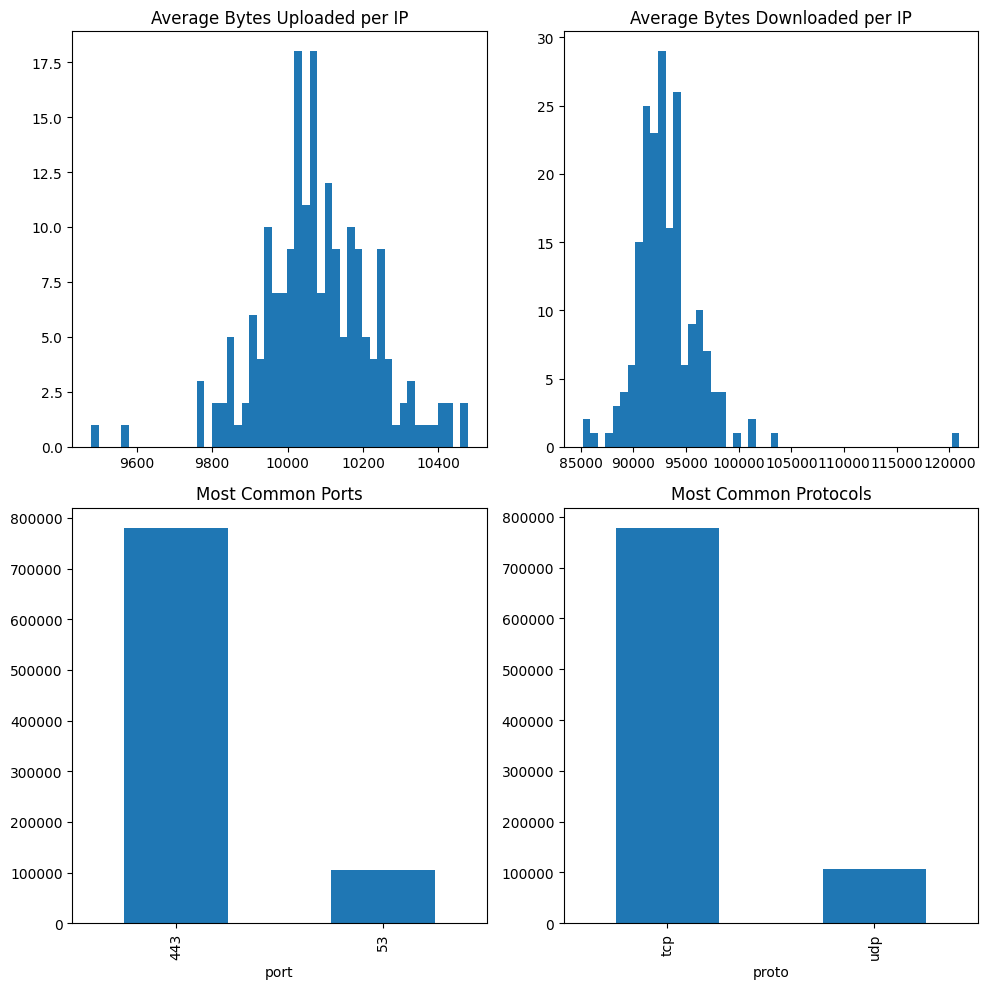

In [ ]:
# # Non-anomalous behavior analysis and description 
# # Import necessary libraries
# import pandas as pd
# import numpy as np
# import ipaddress
# import dns.resolver
# import dns.reversename
# import pygeoip
# import matplotlib.pyplot as plt 

# # Define data file path
# datafile='./../dataset1/data1.parquet'

# # IP geolocalization setup
# gi=pygeoip.GeoIP('./../GeoIP_DBs/GeoIP.dat')
# gi2=pygeoip.GeoIP('./../GeoIP_DBs/GeoIPASNum.dat')

# # Read parquet data file
# data=pd.read_parquet(datafile)

# Get general statistics of the data
general_stats = data.describe(include='all')
print("General Statistics:\n", general_stats)

# Analyze typical behavior of network devices
# Get the average number of bytes uploaded and downloaded by each IP
avg_upload = data.groupby(['src_ip'])['up_bytes'].mean()
avg_download = data.groupby(['src_ip'])['down_bytes'].mean()

# Get the most commonly used ports and protocols
common_ports = data['port'].value_counts()
common_protocols = data['proto'].value_counts()

# Get the average number of connections made per IP
avg_connections = data.groupby(['src_ip']).size()

# Get distribution of internal and external connections
NET = ipaddress.IPv4Network('192.168.100.0/24')
data['is_public'] = data.apply(lambda x: ipaddress.IPv4Address(x['dst_ip']) not in NET, axis=1)
internal_external_distribution = data['is_public'].value_counts()

# Print and visualize the findings
print("Average Upload: \n", avg_upload)
print("Average Download: \n", avg_download)
print("Common Ports: \n", common_ports)
print("Common Protocols: \n", common_protocols)
print("Average Connections per IP: \n", avg_connections)
print("Internal vs External Connections: \n", internal_external_distribution)

# Use matplotlib for visualizing these metrics
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# Average uploaded/downloaded bytes per IP
axs[0, 0].hist(avg_upload, bins=50)
axs[0, 0].set_title('Average Bytes Uploaded per IP')

axs[0, 1].hist(avg_download, bins=50)
axs[0, 1].set_title('Average Bytes Downloaded per IP')

# Common ports and protocols
common_ports.plot(kind='bar', ax=axs[1, 0])
axs[1, 0].set_title('Most Common Ports')

common_protocols.plot(kind='bar', ax=axs[1, 1])
axs[1, 1].set_title('Most Common Protocols')

plt.tight_layout()
plt.show()


In [ ]:
# Anomalous behavior detection, description, and possible causes

# Define data file path
testfile='./../dataset1/test1.parquet'

# Read parquet data file
test=pd.read_parquet(testfile)

# Calculate IQR for uploaded and downloaded bytes
Q1_upload = test['up_bytes'].quantile(0.25)
Q3_upload = test['up_bytes'].quantile(0.75)
IQR_upload = Q3_upload - Q1_upload

Q1_download = test['down_bytes'].quantile(0.25)
Q3_download = test['down_bytes'].quantile(0.75)
IQR_download = Q3_download - Q1_download

# Define thresholds for outliers
threshold_upload_upper = Q3_upload + 1.5 * IQR_upload
threshold_upload_lower = Q1_upload - 1.5 * IQR_upload
threshold_download_upper = Q3_download + 1.5 * IQR_download
threshold_download_lower = Q1_download - 1.5 * IQR_download

# Identify anomalous behavior
anomalies_upload = test[(test['up_bytes'] > threshold_upload_upper) | (test['up_bytes'] < threshold_upload_lower)]
anomalies_download = test[(test['down_bytes'] > threshold_download_upper) | (test['down_bytes'] < threshold_download_lower)]

print("Anomalous upload activity:\n", anomalies_upload)
print("Anomalous download activity:\n", anomalies_download)

Anomalous upload activity:
         timestamp           src_ip           dst_ip proto  port  up_bytes  \
index                                                                       
197800    1224873  192.168.101.160  142.250.184.194   udp   443     33264   
584616    1229426   192.168.101.67  192.168.101.234   tcp   443     32193   
197808    1229442  192.168.101.160  157.240.212.174   tcp   443     36749   
197834    1243928  192.168.101.160     13.107.42.24   tcp   443     42335   
584658    1251926   192.168.101.67  192.168.101.234   tcp   443     31289   
...           ...              ...              ...   ...   ...       ...   
150076    8401338  192.168.101.111  193.126.240.146   tcp   443     36689   
150081    8401819  192.168.101.111  193.126.240.146   tcp   443     31145   
607858    8403960  192.168.101.145  142.250.184.163   udp   443     34722   
150152    8463485  192.168.101.111  192.168.101.239   tcp   443     43807   
608090    8489966  192.168.101.145  192.168.101.

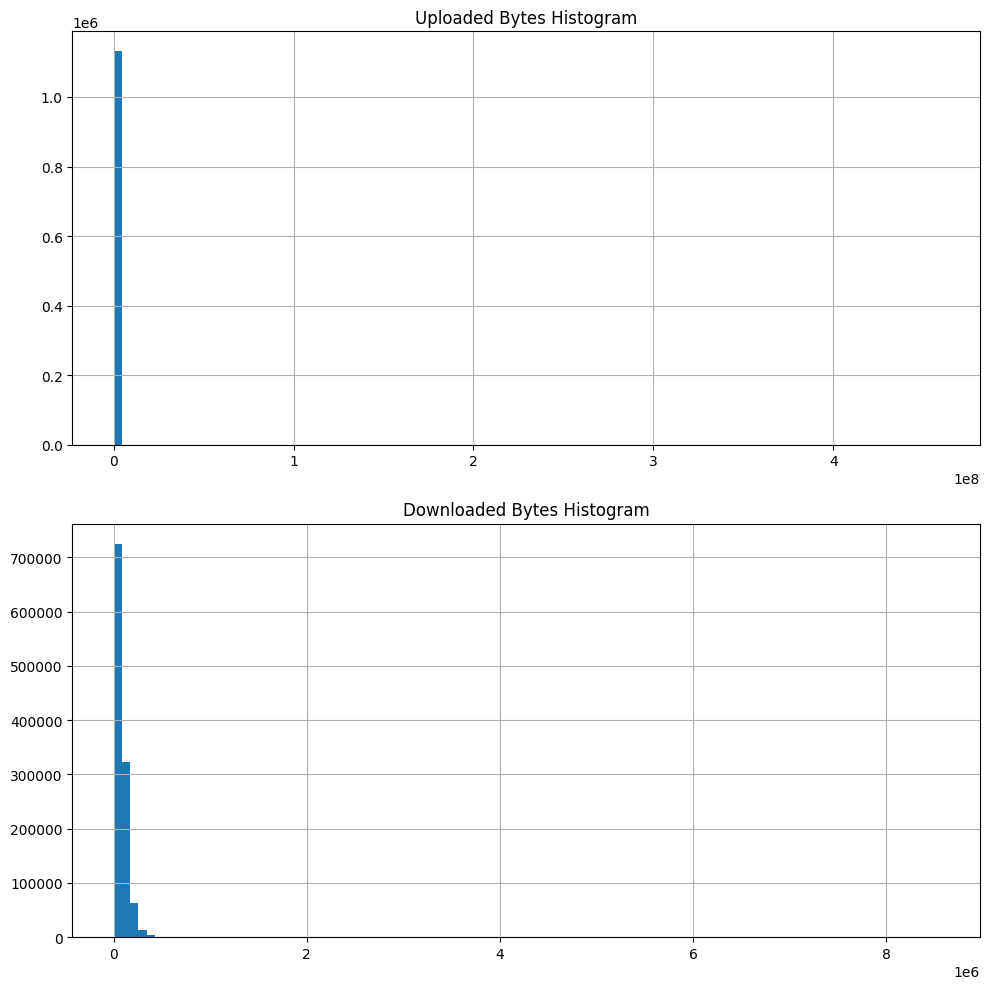

In [ ]:
# Plot histograms for uploaded and downloaded bytes
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Uploaded bytes histogram
test['up_bytes'].hist(bins=100, ax=axs[0])
axs[0].set_title('Uploaded Bytes Histogram')

# Downloaded bytes histogram
test['down_bytes'].hist(bins=100, ax=axs[1])
axs[1].set_title('Downloaded Bytes Histogram')

plt.tight_layout()
plt.show()

In [ ]:
# Define a function to check for outliers based on the mean and standard deviation
def detect_outlier(series, multiplier = 3.0):
    mean = series.mean()
    std = series.std()
    
    # Outliers are defined as values that are 'multiplier' standard deviations away from the mean
    lower_threshold = mean - multiplier * std
    upper_threshold = mean + multiplier * std
    
    # Return a boolean series where True indicates an outlier
    return ((series < lower_threshold) | (series > upper_threshold))

# Apply the function to the uploaded and downloaded bytes
outliers_upload = detect_outlier(test['up_bytes'])
outliers_download = detect_outlier(test['down_bytes'])

print("Anomalous upload activity:\n", test[outliers_upload])
print("Anomalous download activity:\n", test[outliers_download])

Anomalous upload activity:
         timestamp           src_ip           dst_ip proto  port   up_bytes  \
index                                                                        
959619    3118030  192.168.101.209     13.107.42.56   tcp   443   79529780   
959581    3139483  192.168.101.151  142.250.184.139   udp   443   48058944   
959620    3238155  192.168.101.209     13.107.42.56   tcp   443  366891507   
959582    3259619  192.168.101.151  142.250.184.139   udp   443  268638558   
959621    3358125  192.168.101.209     13.107.42.56   tcp   443  243379198   
...           ...              ...              ...   ...   ...        ...   
959614    7099452  192.168.101.151  142.250.184.139   udp   443  145737092   
959615    7219602  192.168.101.151  142.250.184.139   udp   443  134029700   
959616    7339598  192.168.101.151  142.250.184.139   udp   443  155533182   
959617    7459608  192.168.101.151  142.250.184.139   udp   443   41917151   
959618    7579586  192.168.101.151  

# Geo related to timestamp non-anomolous behaviour

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import ipaddress
import dns.resolver
import dns.reversename
import pygeoip
import matplotlib.pyplot as plt 

# Define data file path
datafile='./../dataset1/data1.parquet'

# IP geolocalization setup
gi=pygeoip.GeoIP('./../GeoIP_DBs/GeoIP.dat')
gi2=pygeoip.GeoIP('./../GeoIP_DBs/GeoIPASNum.dat')

# Function to get country from IP
def get_country(ip):
    try:
        return gi.country_name_by_addr(ip)
    except:
        return None

# Read parquet data file
data=pd.read_parquet(datafile)

# Add country information
data['src_country'] = data['src_ip'].apply(get_country)
data['dst_country'] = data['dst_ip'].apply(get_country)

# Make sure timestamp column is datetime
# Assuming 'timestamp' column represents 1/100 of seconds from 0h of the day
# Convert hundredths of a second to microseconds (1/100 sec = 10,000 µs)
data['timestamp'] = pd.to_timedelta(data['timestamp'] * 10000, unit='us')

# Convert timestamp to datetime, setting a start date
data['timestamp'] = pd.Timestamp("2023-01-01") + data['timestamp']

# Get general statistics of the data
general_stats = data.describe(include='all')
print("General Statistics:\n", general_stats)

# Analyze typical behavior of network devices
# ... (Rest of your code) ...

# Traffic by timestamp
hourly_data = data.groupby(data['timestamp'].dt.floor('H')).size()
half_hour_data = data.groupby(data['timestamp'].dt.floor('30T')).size()

# Print and visualize the findings
# ... (Rest of your code) ...

print("Hourly Traffic: \n", hourly_data)
print("Half-Hourly Traffic: \n", half_hour_data)

# Traffic over time
hourly_data.plot(kind='line', ax=axs[2, 1])
axs[2, 1].set_title('Connections over Hour')

half_hour_data.plot(kind='line', ax=axs[3, 1])
axs[3, 1].set_title('Connections over Half-Hour')

plt.tight_layout()
plt.show()


General Statistics:
                             timestamp           src_ip           dst_ip  \
count                          885563           885563           885563   
unique                            NaN              196            18274   
top                               NaN  192.168.101.154  192.168.101.234   
freq                              NaN            11162            78056   
mean    2023-01-01 13:03:11.409734656              NaN              NaN   
min        2023-01-01 03:34:29.690000              NaN              NaN   
25%     2023-01-01 10:37:47.469999872              NaN              NaN   
50%     2023-01-01 12:50:30.470000128              NaN              NaN   
75%        2023-01-01 15:13:54.180000              NaN              NaN   
max        2023-01-01 23:34:49.480000              NaN              NaN   
std                               NaN              NaN              NaN   

         proto           port       up_bytes    down_bytes src_country  \
coun

<Figure size 640x480 with 0 Axes>

In [ ]:
# SIEM rules 
